# ITT Barrio Obrero — Comuna 9, Cali
## Indice de Transformacion Territorial · 5 Dimensiones · 2023-2025
---
**Zona:** Barrio Obrero (poligono unico, sin tramos)  
**Normalizacion:** ref_min / ref_max fijos por indicador (juicio experto)  
**Dimensiones:** Seguridad (30%) · Movilidad (25%) · Entorno Urbano (20% ref) · Educ y Des (13% ref) · Cohesion Social (12%)  
**Periodo:** 2023 - 2025


## Celda 1 — Instalacion de dependencias


In [1]:
# Descomentar en Colab
!pip install geopandas pyproj shapely openpyxl matplotlib seaborn folium -q

import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
for p in ['geopandas','pyproj','shapely','openpyxl','seaborn','folium']: check_pkg(p)
print('Dependencias verificadas')


Dependencias verificadas


## Celda 2 — Importaciones y configuracion


In [2]:
import json, os, warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import folium
warnings.filterwarnings('ignore')

C_SEG='#1B4F8A'; C_MOV='#E8852A'; C_COH='#7B1FA2'; C_ITT='#2E7D32'; BG='#F4F6F9'
NIVEL_COLORS = {'Emergencia':'#E53935','Consolidacion':'#FB8C00','Avance':'#43A047','Transformacion':'#1E88E5'}
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':'white','font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
print('Configuracion visual lista')


Configuracion visual lista


## Celda 3A — Subida ZIP (Colab)


In [3]:
import zipfile
from google.colab import files
print('Selecciona obrero.zip...')
uploaded = files.upload()
for fn, content in uploaded.items():
    with open(f'/content/{fn}','wb') as f: f.write(content)
    with zipfile.ZipFile(f'/content/{fn}','r') as z: z.extractall('/content/')
    print(f'Descomprimido: {fn}')
print('Listo.')


Selecciona obrero.zip...


Saving obrero.zip to obrero.zip
Descomprimido: obrero.zip
Listo.


## Celda 3 — Parametros, rutas y umbrales ref_min / ref_max
Los umbrales definen el rango de normalizacion de cada indicador.  
Ajustarlos segun juicio experto, datos historicos o comparacion con otras zonas.


In [4]:
import os

BASE = '/content/obrero/Geojson_Barrio_Obrero/'
# BASE = './obrero/Geojson_Barrio_Obrero/'   # local

PATHS = {
    'poligono':    BASE + 'Geojson_Barrio_Obrero.geojson',
    'homicidios':  BASE + 'HOMICIDIOS_2023_2025_Obrero.geojson',
    'hurtos':      BASE + 'HURTOS_2023_2025_OBRERO.geojson',
    'siniestros':  BASE + 'BD_SINIESTROS_2023_2025_COMUNA_BARRIO_OBRERO.geojson',
    'vif':         BASE + 'VIOLENCIA_INTRAFAMILIAR_2023_2025_OBRERO.geojson',
    'comparendos': BASE + 'COMPARENDOS_2023_2025_OBRERO.geojson',
    'arboles':     BASE + 'Arboles_Dagma_OBRERO.geojson',
    'sedes':       BASE + 'Sedes_educativas_oficiales_OBRERO.geojson',
    'cai':         BASE + 'CAI_MECAL_CALI_OBRERO.geojson',
}

ANIOS = [2023, 2024, 2025]
ZONA_NOMBRE = 'Barrio Obrero — Comuna 9, Cali'

# ══════════════════════════════════════════════════════════
# PESOS por dimension (deben sumar 1.0)
# ══════════════════════════════════════════════════════════
PESOS = {
    'Seguridad': 0.30, 'Movilidad': 0.25,
    'EntornoU':  0.20, 'EducDes':   0.13, 'Cohesion':  0.12,
}

# ══════════════════════════════════════════════════════════
# REF_MIN y REF_MAX por indicador (juicio experto)
# Calibrados para un barrio pequeno de Cali (~5K hab)
# Ajustar segun conocimiento local o benchmarks
# ══════════════════════════════════════════════════════════
REFS = {
    #                  ref_min  ref_max  inverso  descripcion
    'homicidios':     (0,       5,       True,    'Homicidios anuales en el barrio'),
    'hurtos':         (10,      60,      True,    'Hurtos anuales en el barrio'),
    'siniestralidad': (1,       15,      True,    'Siniestros viales anuales'),
    'lesionados':     (1,       12,      True,    'Accidentes con lesionados anuales'),
    'mortales':       (0,       3,       True,    'Accidentes mortales anuales'),
    'vif':            (1,       15,      True,    'Violencia intrafamiliar anual'),
    'rinas':          (0,       10,      True,    'Rinas / conflictividad anual'),
}

# ══════════════════════════════════════════════════════════
# Scores referentes para dimensiones SIN datos propios
# Fuente: Pulmon de Oriente
# ══════════════════════════════════════════════════════════
REF_ENTORNO_U      = 39.2   # Entorno Urbano
REF_EDUC_DES       = 54.9   # Educacion y Desarrollo
REF_VULNERABILIDAD = 54.1   # Concentracion vulnerabilidad (neutro, Cohesion)

# Verificar archivos
ok = True
for n, r in PATHS.items():
    e = os.path.exists(r)
    print(f'  {chr(9989) if e else chr(10060)}  {n}')
    if not e: ok = False
print()
print('Periodo:', f'{ANIOS[0]}-{ANIOS[-1]}')
print('Pesos:', ' | '.join(f'{k}={v:.0%}' for k,v in PESOS.items()))
print()
print('Umbrales ref_min / ref_max:')
for ind, (rmin, rmax, inv, desc) in REFS.items():
    print(f'  {ind:18s}  [{rmin:>4} - {rmax:>4}]  inv={inv}  | {desc}')


  ✅  poligono
  ✅  homicidios
  ✅  hurtos
  ✅  siniestros
  ✅  vif
  ✅  comparendos
  ✅  arboles
  ✅  sedes
  ✅  cai

Periodo: 2023-2025
Pesos: Seguridad=30% | Movilidad=25% | EntornoU=20% | EducDes=13% | Cohesion=12%

Umbrales ref_min / ref_max:
  homicidios          [   0 -    5]  inv=True  | Homicidios anuales en el barrio
  hurtos              [  10 -   60]  inv=True  | Hurtos anuales en el barrio
  siniestralidad      [   1 -   15]  inv=True  | Siniestros viales anuales
  lesionados          [   1 -   12]  inv=True  | Accidentes con lesionados anuales
  mortales            [   0 -    3]  inv=True  | Accidentes mortales anuales
  vif                 [   1 -   15]  inv=True  | Violencia intrafamiliar anual
  rinas               [   0 -   10]  inv=True  | Rinas / conflictividad anual


## Celda 3B — Proxy de Entorno Urbano para Barrio Obrero

Esta celda recalcula `REF_ENTORNO_U` usando el Excel de `deficit habitacional` en `data/referencia/`.

- Base territorial: `Comuna 9`, usada como proxy para `Barrio Obrero`.
- Variable principal: `Deficit Cualitativo`.
- Variable de intensidad: `Deficit Cualitativo / Deficit Habitacional`.
- Regla de score: ambos componentes se normalizan a `0-100` con referencias fijas y luego se promedian.
- Si el Excel no aparece o no encuentra la Comuna 9, el notebook conserva el valor previo de `REF_ENTORNO_U`.


In [ ]:
import os
import pandas as pd
import numpy as np

# Proxy de Entorno Urbano para Barrio Obrero usando deficit habitacional (Comuna 9).
# Este bloque sustituye el referente fijo solo para esta corrida si encuentra el Excel.
# Si falla la lectura, se mantiene el valor previo heredado de Pulmon de Oriente.
REF_ENTORNO_U = globals().get('REF_ENTORNO_U', 39.2)
FUENTE_ENTORNO_U = globals().get('FUENTE_ENTORNO_U', 'Pulmon de Oriente (referente fijo)')
DETALLE_ENTORNO_U = globals().get('DETALLE_ENTORNO_U', f'Score fijo heredado={REF_ENTORNO_U:.1f}')

PATH_PROXY_ENTORNO = [
    '/content/itt_repos_cali/data/referencia/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx',
    'data/referencia/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx',
    './data/referencia/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx',
]

proxy_path = next((p for p in PATH_PROXY_ENTORNO if os.path.exists(p)), None)
if proxy_path is None:
    print('No se encontro el Excel de referencia. REF_ENTORNO_U conserva su valor actual:', REF_ENTORNO_U)
else:
    def score_ref_proxy(valor, ref_min, ref_max, inverso=True):
        if ref_max == ref_min:
            return 100.0
        raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
        return 100 - raw if inverso else raw

    df_proxy = pd.read_excel(proxy_path, sheet_name='Hoja1')
    df_proxy.columns = [str(c).strip() for c in df_proxy.columns]

    # Se toma la Comuna 9 como aproximacion territorial a Barrio Obrero.
    col_area = 'Comuna o Corregimiento'
    col_total = 'Déficit Habitacional'
    col_cual = 'Déficit Cualitativo'

    fila_c9 = df_proxy.loc[df_proxy[col_area].astype(str).str.strip() == '9']
    if fila_c9.empty:
        print('No se encontro la Comuna 9 en el Excel. REF_ENTORNO_U conserva su valor actual:', REF_ENTORNO_U)
    else:
        deficit_total = float(fila_c9.iloc[0][col_total])
        deficit_cual = float(fila_c9.iloc[0][col_cual])
        deficit_pct = (deficit_cual / deficit_total) * 100 if deficit_total else np.nan

        # Referencias fijas de Hoja1 (38 comunas/corregimientos), no min-max de la muestra local.
        REF_MIN_DEFICIT_CUAL = 86.0
        REF_MAX_DEFICIT_CUAL = 20179.0
        REF_MIN_DEFICIT_PCT = 69.8
        REF_MAX_DEFICIT_PCT = 96.6

        # Componente 1: volumen absoluto de deficit cualitativo.
        score_proxy_volumen = score_ref_proxy(deficit_cual, REF_MIN_DEFICIT_CUAL, REF_MAX_DEFICIT_CUAL, True)
        # Componente 2: intensidad relativa del deficit cualitativo dentro del deficit total.
        score_proxy_intensidad = score_ref_proxy(deficit_pct, REF_MIN_DEFICIT_PCT, REF_MAX_DEFICIT_PCT, True)

        # Proxy final de Entorno Urbano = promedio simple de ambos componentes.
        REF_ENTORNO_U = round((score_proxy_volumen + score_proxy_intensidad) / 2, 1)
        FUENTE_ENTORNO_U = 'Proxy por deficit habitacional (Comuna 9)'
        DETALLE_ENTORNO_U = (
            f'Deficit cualitativo={deficit_cual:,.0f}; '
            f'proporcion={deficit_pct:.1f}%; '
            f'score_volumen={score_proxy_volumen:.1f}; '
            f'score_intensidad={score_proxy_intensidad:.1f}; '
            f'promedio={REF_ENTORNO_U:.1f}'
        )

        print('Proxy Entorno Urbano activado para Barrio Obrero')
        print('Fuente:', proxy_path)
        print('Base territorial:', 'Comuna 9 (proxy para Barrio Obrero)')
        print(f'Deficit cualitativo: {deficit_cual:,.0f}')
        print(f'Deficit cualitativo / deficit habitacional: {deficit_pct:.1f}%')
        print(f'Score proxy volumen: {score_proxy_volumen:.1f}')
        print(f'Score proxy intensidad: {score_proxy_intensidad:.1f}')
        print(f'Nuevo REF_ENTORNO_U: {REF_ENTORNO_U:.1f}')


## Celda 4 — Carga de datos


In [5]:
def load_gj(path):
    with open(path, encoding='utf-8') as f: return json.load(f)

gdf_barrio = gpd.read_file(PATHS['poligono'])
gdf_barrio_wgs = gdf_barrio.to_crs('EPSG:4326')

raw_hom  = load_gj(PATHS['homicidios'])
raw_hur  = load_gj(PATHS['hurtos'])
raw_sin  = load_gj(PATHS['siniestros'])
raw_vif  = load_gj(PATHS['vif'])
raw_comp = load_gj(PATHS['comparendos'])
raw_arb  = load_gj(PATHS['arboles'])
raw_sed  = load_gj(PATHS['sedes'])
raw_cai  = load_gj(PATHS['cai'])

for n, r in [('Homicidios',raw_hom),('Hurtos',raw_hur),('Siniestros',raw_sin),
             ('VIF',raw_vif),('Comparendos',raw_comp),('Arboles',raw_arb),
             ('Sedes',raw_sed),('CAI',raw_cai)]:
    print(f'  {n:15s}: {len(r["features"]):>4} registros')


  Homicidios     :    3 registros
  Hurtos         :  111 registros
  Siniestros     :   15 registros
  VIF            :   20 registros
  Comparendos    :  332 registros
  Arboles        :  151 registros
  Sedes          :    2 registros
  CAI            :    1 registros


## Celda 5 — Mapa de geolocalizacion


In [6]:
centroid = gdf_barrio_wgs.geometry.centroid.iloc[0]
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=17, tiles='CartoDB positron')

folium.GeoJson(gdf_barrio_wgs.__geo_interface__, name='Poligono Barrio Obrero',
    style_function=lambda x: {'fillColor':'#2E7D32','color':'#1B4F8A','weight':2,'fillOpacity':0.1}).add_to(m)

capas = [
    ('Homicidios',  raw_hom, 'FECHA_HECH','X','Y','red','exclamation-sign'),
    ('Hurtos',      raw_hur, 'FECHA_HECH','X','Y','blue','shopping-cart'),
    ('Siniestros',  raw_sin, 'Fecha',None,None,'orange','road'),
    ('VIF',         raw_vif, 'FECHA_HECH','X','Y','purple','home'),
]
for nombre, raw, col_f, cx, cy, color, icon in capas:
    fg = folium.FeatureGroup(name=nombre)
    for feat in raw['features']:
        p = feat['properties']
        if feat.get('geometry') and feat['geometry'].get('coordinates'):
            lon, lat = feat['geometry']['coordinates'][:2]
        elif cx and cx in p: lon, lat = p[cx], p[cy]
        else: continue
        fecha = str(p.get(col_f,''))[:10]
        folium.Marker([lat,lon], popup=f'<b>{nombre}</b><br>{fecha}',
            icon=folium.Icon(color=color, icon=icon, prefix='glyphicon')).add_to(fg)
    fg.add_to(m)

fg_r = folium.FeatureGroup(name='Rinas')
for feat in raw_comp['features']:
    p = feat['properties']
    if p.get('agrupado')!='RIÑAS': continue
    if p.get('lat') and p.get('lon'):
        folium.Marker([p['lat'],p['lon']], popup=f'Rina<br>{str(p.get("fecha_hech",""))[:10]}',
            icon=folium.Icon(color='pink',icon='flash',prefix='glyphicon')).add_to(fg_r)
fg_r.add_to(m)

fg_a = folium.FeatureGroup(name='Arboles DAGMA', show=False)
for feat in raw_arb['features']:
    p = feat['properties']
    if p.get('latitud') and p.get('longitud'):
        folium.CircleMarker([p['latitud'],p['longitud']], radius=3, color='green',
            fill=True, fillOpacity=0.6).add_to(fg_a)
fg_a.add_to(m)

for feat in raw_sed['features']:
    p = feat['properties']
    if p.get('Latitud_D'):
        folium.Marker([p['Latitud_D'],p['Longitud_D']],
            popup=f'<b>{p.get("NombreSede","Sede")}</b>',
            icon=folium.Icon(color='cadetblue',icon='education',prefix='glyphicon')).add_to(m)

for feat in raw_cai['features']:
    p = feat['properties']
    if p.get('LATITUD'):
        folium.Marker([p['LATITUD'],p['LONGITUD']],
            popup=f'<b>{p.get("UNIDAD","CAI")}</b>',
            icon=folium.Icon(color='darkblue',icon='tower',prefix='glyphicon')).add_to(m)

folium.LayerControl().add_to(m)
m


## Celda 6 — Procesamiento de indicadores


In [7]:
def procesar(raw, col_fecha, filtro=None, filtro_col=None):
    df = pd.DataFrame([f['properties'] for f in raw['features']])
    if filtro and filtro_col: df = df[df[filtro_col]==filtro].copy()
    df['_fecha'] = pd.to_datetime(df[col_fecha])
    df['año'] = df['_fecha'].dt.year
    df['trimestre'] = df['_fecha'].dt.quarter
    return df[df['año'].isin(ANIOS)].copy()

def agg_anual(df): return df.groupby('año').size().reindex(ANIOS, fill_value=0)
def agg_trim(df):
    idx = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
    return df.groupby(['año','trimestre']).size().reindex(idx, fill_value=0)

df_hom = procesar(raw_hom, 'FECHA_HECH')
df_hur = procesar(raw_hur, 'FECHA_HECH')
df_sin = procesar(raw_sin, 'Fecha')
df_les = df_sin[df_sin['Tipo_Confi']=='Lesiones'].copy()
df_mor = df_sin[df_sin['Tipo_Confi']=='Mortal'].copy()
df_vif = procesar(raw_vif, 'FECHA_HECH')
df_rin = procesar(raw_comp, 'fecha_hech', filtro='RIÑAS', filtro_col='agrupado')

# Tabla anual
base = pd.DataFrame({'año': ANIOS})
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    base[nombre] = agg_anual(df_src).values

# Tabla trimestral
idx_t = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
corr_trim = pd.DataFrame(index=idx_t).reset_index()
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    ser = agg_trim(df_src).reset_index()
    ser.columns = ['año','trimestre',nombre]
    corr_trim = corr_trim.merge(ser, on=['año','trimestre'], how='left').fillna({nombre:0})
corr_trim['periodo'] = corr_trim['año'].astype(str) + '-Q' + corr_trim['trimestre'].astype(str)

print('Indicadores anuales:')
print(base.to_string(index=False))
print()
print('Indicadores trimestrales:')
print(corr_trim.to_string(index=False))


Indicadores anuales:
 año  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas
2023           0      31               8           6         1    9      4
2024           2      47               4           3         0    4      2
2025           1      33               3           2         0    7      2

Indicadores trimestrales:
 año  trimestre  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas periodo
2023          1           0      13               6           4         1    6      2 2023-Q1
2023          2           0       8               1           1         0    2      2 2023-Q2
2023          3           0       6               1           1         0    1      0 2023-Q3
2023          4           0       4               0           0         0    0      0 2023-Q4
2024          1           2       9               2           1         0    1      0 2024-Q1
2024          2           0      16               0           0         0    2      2 20

## Celda 7 — Normalizacion con ref_min / ref_max e ITT
Usa umbrales fijos definidos en Celda 3 (no min-max relativo de la muestra).  
Para `Entorno Urbano`, esta celda toma el valor vigente de `REF_ENTORNO_U`: puede ser el referente fijo original o el proxy calculado en la Celda 3B.


In [ ]:
def score_ref(valor, ref_min, ref_max, inverso):
    """Normaliza un valor con umbrales fijos ref_min/ref_max.
    Si inverso=True, menor valor = mejor score."""
    if ref_max == ref_min: return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

# Aplicar normalizacion con refs fijos a los indicadores observados.
for ind, (rmin, rmax, inv, desc) in REFS.items():
    base[f'score_{ind}'] = base[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

# Scores por dimension.
# Entorno Urbano no se calcula con datos del poligono en este notebook;
# se toma del valor vigente de REF_ENTORNO_U, que puede venir del referente fijo
# o del proxy documentado en la Celda 3B.
base['score_seguridad'] = (base['score_homicidios'] + base['score_hurtos']) / 2
base['score_movilidad'] = (base['score_siniestralidad'] + base['score_lesionados'] + base['score_mortales']) / 3
base['score_cohesion']  = (base['score_vif'] + base['score_rinas'] + REF_VULNERABILIDAD) / 3
base['score_entorno_u'] = REF_ENTORNO_U
base['score_educ_des']  = REF_EDUC_DES

# ITT Global.
base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['EducDes']   * base['score_educ_des'] +
    PESOS['Cohesion']  * base['score_cohesion']
)

def clasificar(v):
    if v < 40: return 'Emergencia'
    elif v < 60: return 'Consolidacion'
    elif v < 80: return 'Avance'
    else: return 'Transformacion'

base['nivel'] = base['ITT'].apply(clasificar)

# Mostrar tabla detallada y dejar explicito el Entorno Urbano usado en el ITT.
print('ITT Barrio Obrero — Normalizacion con ref_min/ref_max fijos')
print()
print(f'Entorno Urbano usado en el ITT: {REF_ENTORNO_U:.1f}')
print(f'Fuente Entorno Urbano: {globals().get("FUENTE_ENTORNO_U", "No especificada")}')
print(f'Detalle Entorno Urbano: {globals().get("DETALLE_ENTORNO_U", "Sin detalle adicional")}')
print()
print('Scores por indicador:')
score_cols = [c for c in base.columns if c.startswith('score_')]
print(base[['año'] + [c for c in base.columns if c.startswith('score_') and 'seguridad' not in c and 'movilidad' not in c and 'cohesion' not in c and 'entorno' not in c and 'educ' not in c]].round(1).to_string(index=False))
print()
print('Scores por dimension e ITT:')
print(base[['año','score_seguridad','score_movilidad','score_cohesion','score_entorno_u','score_educ_des','ITT','nivel']].round(1).to_string(index=False))
print()
print('Detalle contribucion al ITT:')
for _, row in base.iterrows():
    año = int(row['año'])
    contribs = {d: row[f'score_{k}']*PESOS[d] for d,k in [('Seguridad','seguridad'),('Movilidad','movilidad'),
        ('EntornoU','entorno_u'),('EducDes','educ_des'),('Cohesion','cohesion')]}
    det = ' + '.join(f'{d}={v:.1f}' for d,v in contribs.items())
    print(f'  {año}: {det} = ITT {row["ITT"]:.1f} ({row["nivel"]})')


## Celda 8 — Cards de metricas clave


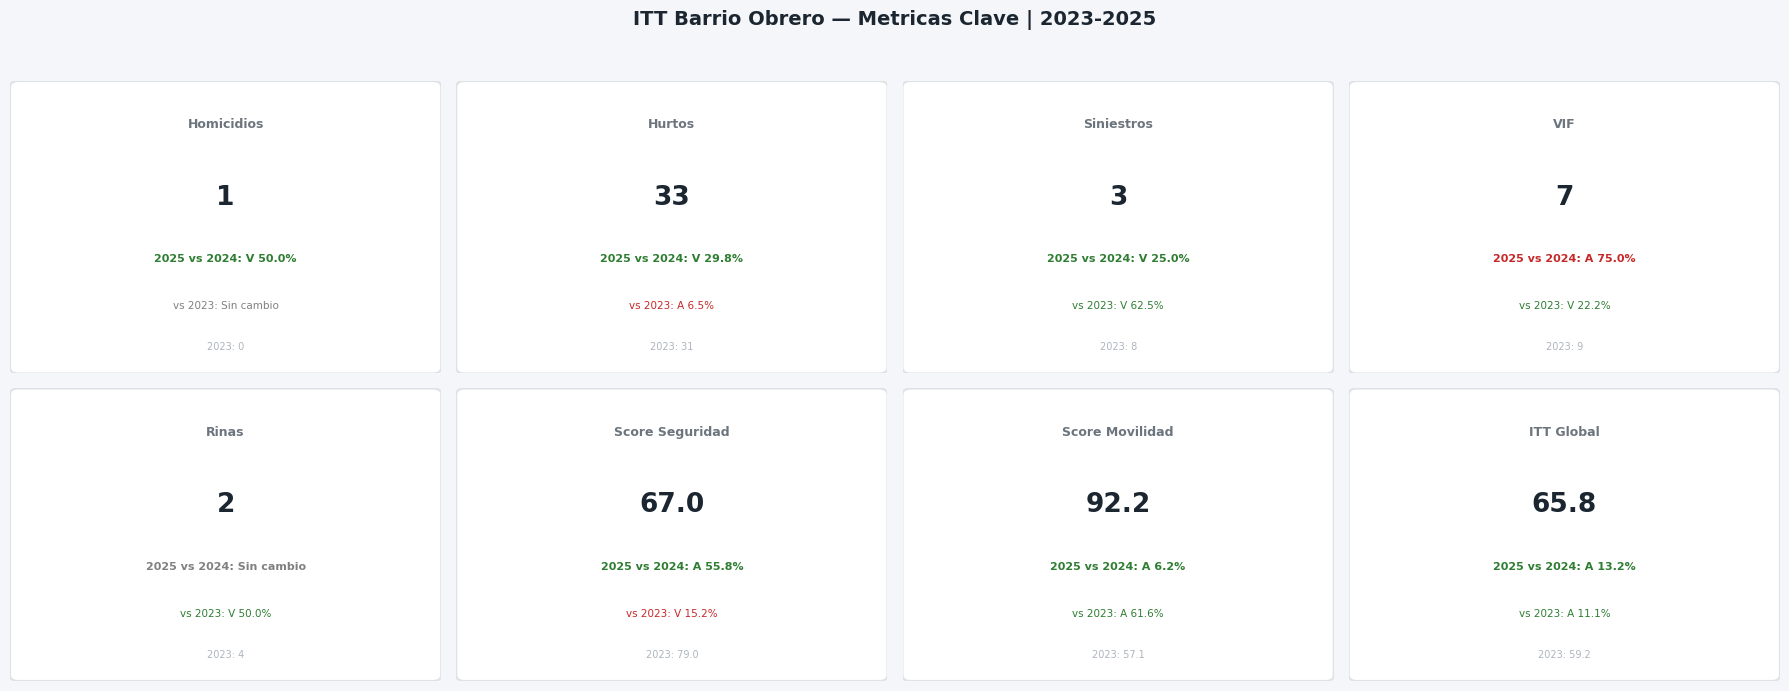

In [9]:
def safe_pct(new, old):
    if old == 0: return 0.0
    return (new - old) / old * 100

def arrow(pct, inv=True):
    if abs(pct) < 1: return 'Sin cambio', 'gray'
    if inv: return (f'V {abs(pct):.1f}%','#2E7D32') if pct<0 else (f'A {abs(pct):.1f}%','#C62828')
    else:  return (f'A {abs(pct):.1f}%','#2E7D32') if pct>0 else (f'V {abs(pct):.1f}%','#C62828')

año_ini, año_ant, año_ult = ANIOS[0], ANIOS[-2], ANIOS[-1]
d_ini = base[base['año']==año_ini].iloc[0]
d_ant = base[base['año']==año_ant].iloc[0]
d_ult = base[base['año']==año_ult].iloc[0]

cards = [
    ('Homicidios',int(d_ini['homicidios']),int(d_ant['homicidios']),int(d_ult['homicidios']),True),
    ('Hurtos',int(d_ini['hurtos']),int(d_ant['hurtos']),int(d_ult['hurtos']),True),
    ('Siniestros',int(d_ini['siniestralidad']),int(d_ant['siniestralidad']),int(d_ult['siniestralidad']),True),
    ('VIF',int(d_ini['vif']),int(d_ant['vif']),int(d_ult['vif']),True),
    ('Rinas',int(d_ini['rinas']),int(d_ant['rinas']),int(d_ult['rinas']),True),
    ('Score Seguridad',d_ini['score_seguridad'],d_ant['score_seguridad'],d_ult['score_seguridad'],False),
    ('Score Movilidad',d_ini['score_movilidad'],d_ant['score_movilidad'],d_ult['score_movilidad'],False),
    ('ITT Global',d_ini['ITT'],d_ant['ITT'],d_ult['ITT'],False),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), facecolor=BG)
fig.suptitle(f'ITT Barrio Obrero — Metricas Clave | {año_ini}-{año_ult}',
             fontsize=14, fontweight='bold', color='#1B2631', y=0.98)
for i, (titulo, v_ini, v_ant, v_ult, inv) in enumerate(cards):
    ax = axes[i//4][i%4]; ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    rect = mpatches.FancyBboxPatch((0.02,0.02),0.96,0.96, boxstyle='round,pad=0.02',
        linewidth=1.5, edgecolor='#DEE2E6', facecolor='white')
    ax.add_patch(rect)
    ax.text(0.5,0.85, titulo, ha='center', va='center', fontsize=9, color='#6C757D', fontweight='bold')
    val_d = f'{v_ult:.1f}' if isinstance(v_ult,float) else str(v_ult)
    ax.text(0.5,0.60, val_d, ha='center', va='center', fontsize=19, fontweight='bold', color='#1B2631')
    pct1 = safe_pct(v_ult, v_ant)
    ar1, col1 = arrow(pct1, inv)
    ax.text(0.5,0.38, f'{año_ult} vs {año_ant}: {ar1}', ha='center', fontsize=8, color=col1, fontweight='bold')
    pct2 = safe_pct(v_ult, v_ini)
    ar2, col2 = arrow(pct2, inv)
    ax.text(0.5,0.22, f'vs {año_ini}: {ar2}', ha='center', fontsize=7.5, color=col2)
    ref = f'{v_ini:.1f}' if isinstance(v_ini,float) else str(v_ini)
    ax.text(0.5,0.08, f'{año_ini}: {ref}', ha='center', fontsize=7, color='#ADB5BD')

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('itt_obrero_cards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 9 — Heatmap: Dimension Seguridad


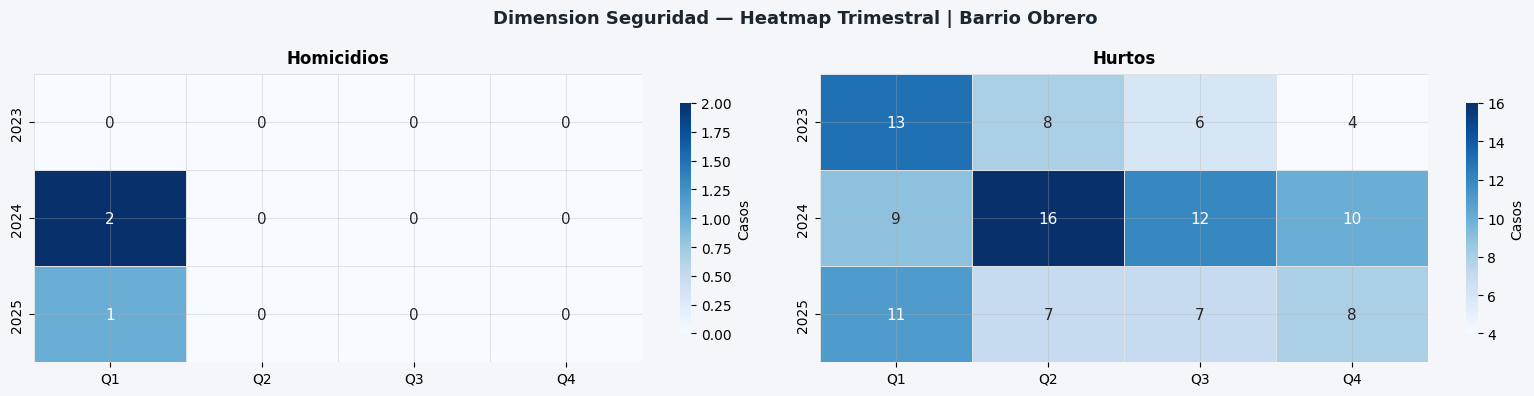

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle('Dimension Seguridad — Heatmap Trimestral | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h, cmap_h in [
    (axes[0],'homicidios','Homicidios','Blues'),
    (axes[1],'hurtos','Hurtos','Blues')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap_h,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_obrero_heatmap_seg.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 10 — Heatmap: Dimension Movilidad


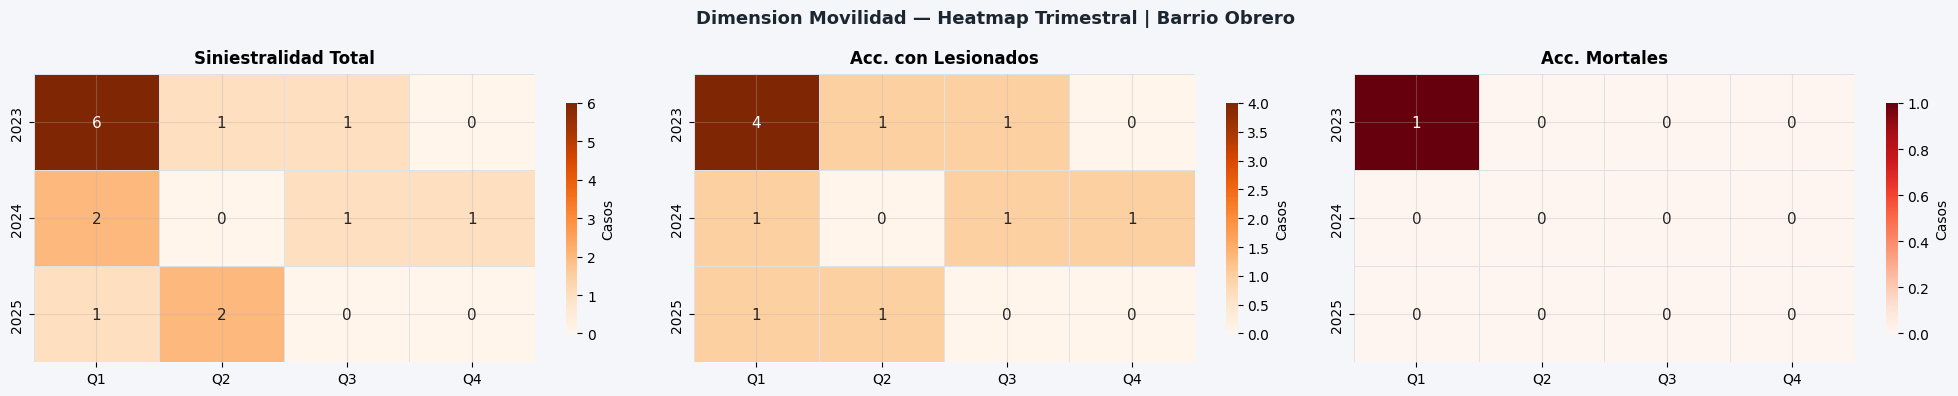

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle('Dimension Movilidad — Heatmap Trimestral | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h, cmap_h in [
    (axes[0],'siniestralidad','Siniestralidad Total','Oranges'),
    (axes[1],'lesionados','Acc. con Lesionados','Oranges'),
    (axes[2],'mortales','Acc. Mortales','Reds')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap_h,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_obrero_heatmap_mov.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 11 — Heatmap: Dimension Cohesion Social


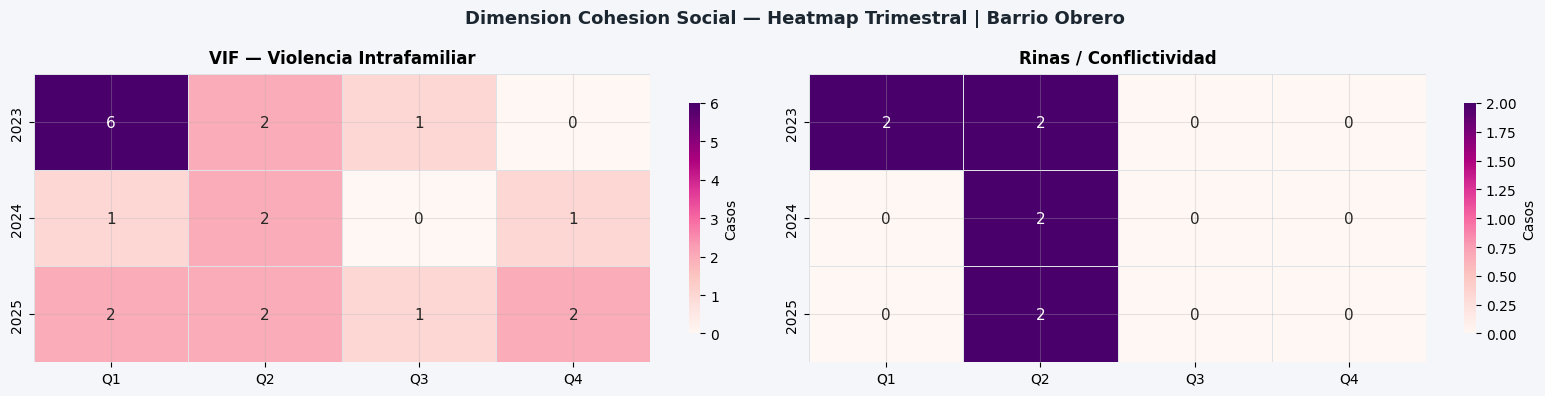

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle('Dimension Cohesion Social — Heatmap Trimestral | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h in [
    (axes[0],'vif','VIF — Violencia Intrafamiliar'),
    (axes[1],'rinas','Rinas / Conflictividad')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdPu',
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_obrero_heatmap_coh.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 12 — Evolucion trimestral: Seguridad


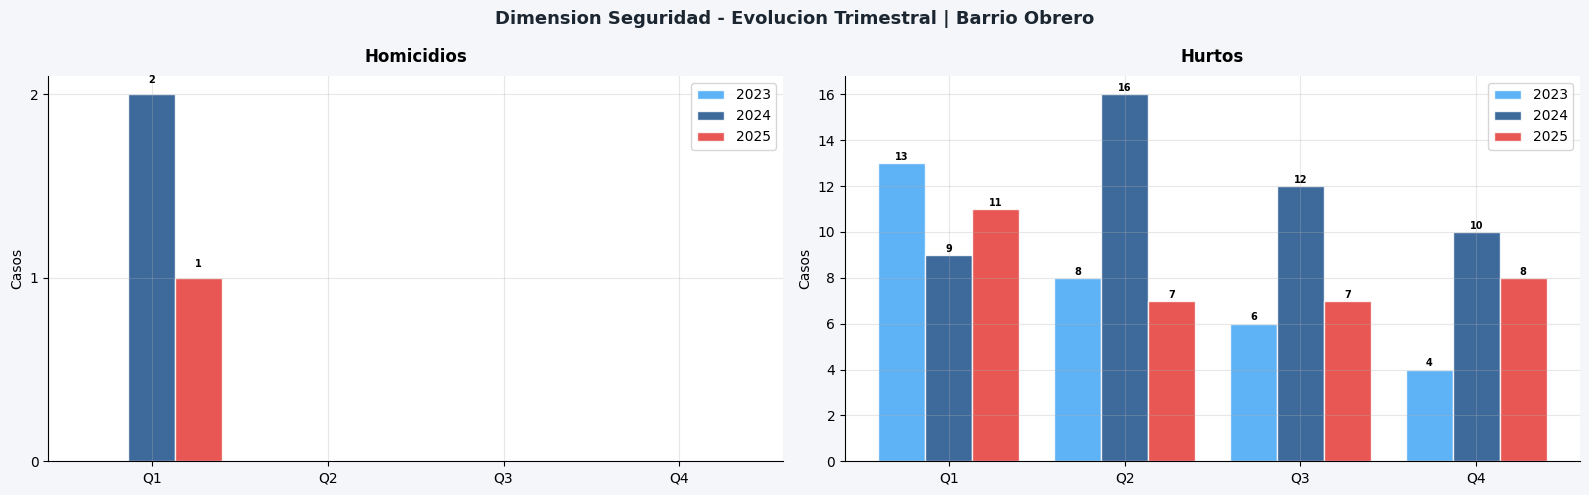

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
titulo = 'Dimension Seguridad - Evolucion Trimestral | Barrio Obrero'
fig.suptitle(titulo, fontsize=13, fontweight='bold', color='#1B2631')
x = np.arange(4); n = len(ANIOS); w = 0.8/n
COLORES = ['#42A5F5','#1B4F8A','#E53935']
for ax, col, tp in [(axes[0],'homicidios','Homicidios'),(axes[1],'hurtos','Hurtos')]:
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim['año']==año][col].values
        offset = (idx-n/2+0.5)*w
        b = ax.bar(x+offset, vals, w, label=str(año), color=COLORES[idx%3], alpha=0.85, edgecolor='white')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.05, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=10)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig('itt_obrero_seg_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 13 — Evolucion trimestral: Movilidad


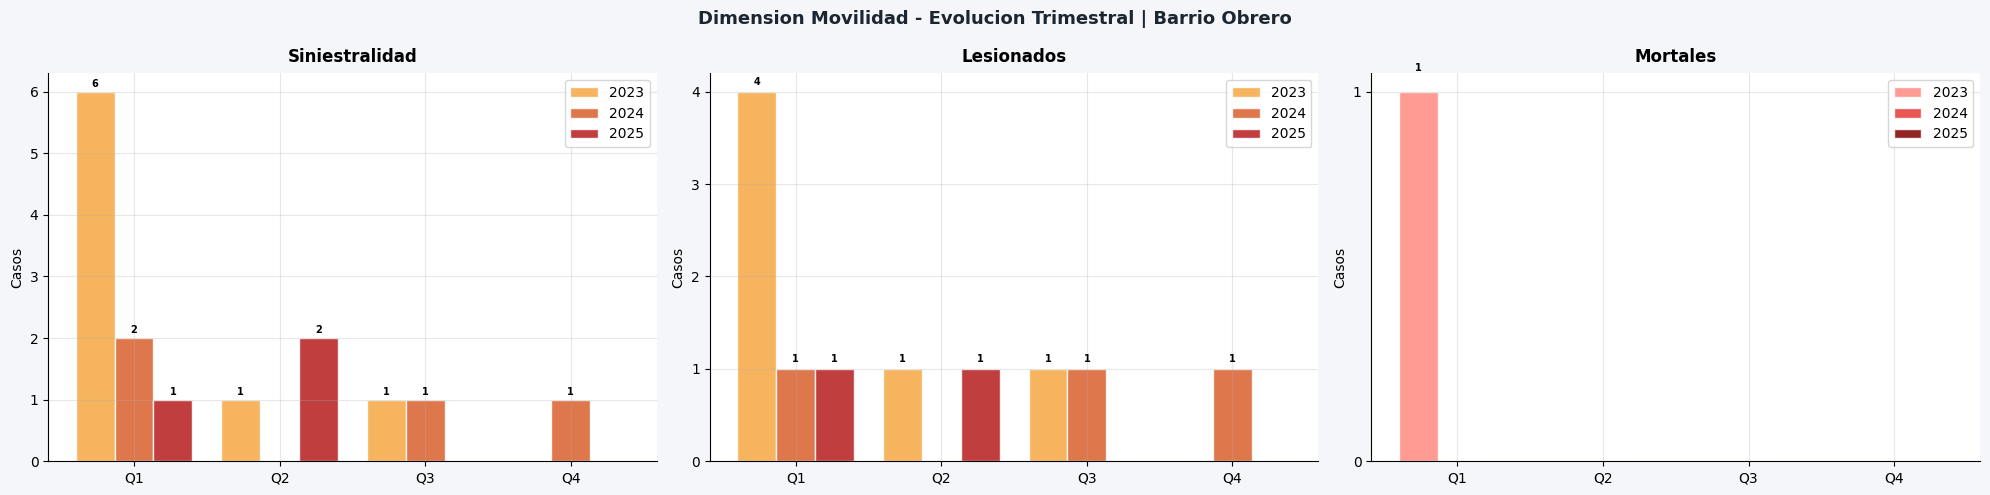

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
titulo = 'Dimension Movilidad - Evolucion Trimestral | Barrio Obrero'
fig.suptitle(titulo, fontsize=13, fontweight='bold', color='#1B2631')
CMOV = [['#F5A742','#D95F2B','#B71C1C'],['#F5A742','#D95F2B','#B71C1C'],['#FF8A80','#E53935','#7F0000']]
for pi,(ax,col,tp) in enumerate([(axes[0],'siniestralidad','Siniestralidad'),(axes[1],'lesionados','Lesionados'),(axes[2],'mortales','Mortales')]):
    c = CMOV[pi]
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim['año']==año][col].values
        offset = (idx-n/2+0.5)*w
        b = ax.bar(x+offset, vals, w, label=str(año), color=c[idx%3], alpha=0.85, edgecolor='white')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.05, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=8)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig('itt_obrero_mov_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 14 — Evolucion trimestral: Cohesion Social


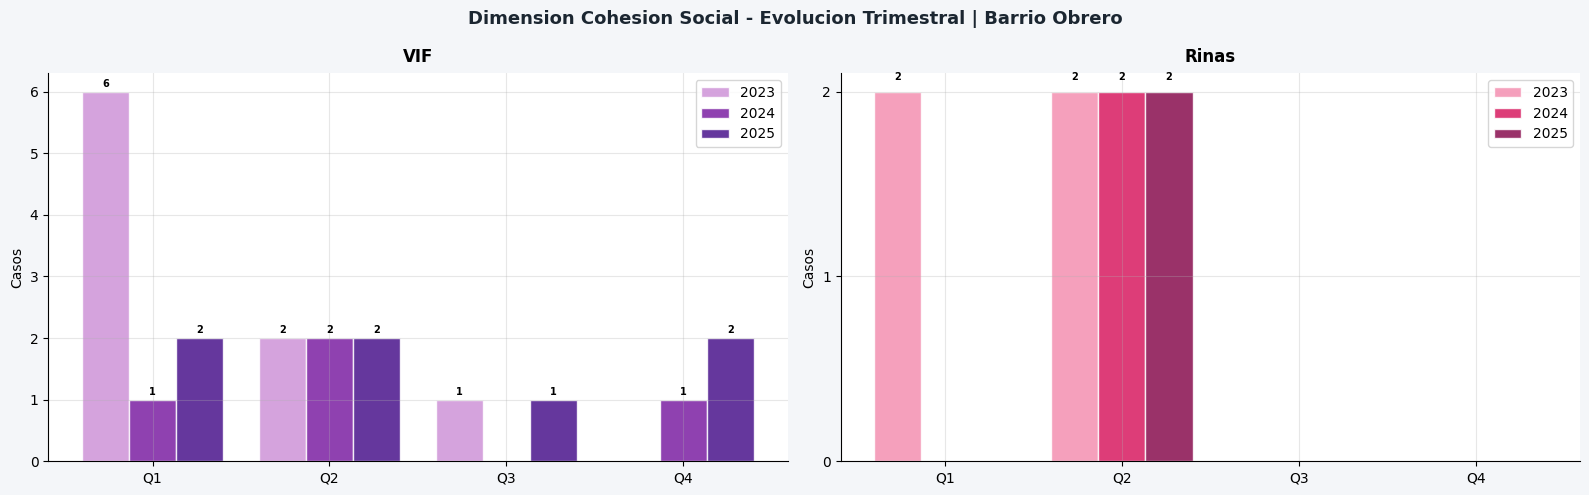

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
titulo = 'Dimension Cohesion Social - Evolucion Trimestral | Barrio Obrero'
fig.suptitle(titulo, fontsize=13, fontweight='bold', color='#1B2631')
CVIF = ['#CE93D8','#7B1FA2','#4A148C']; CRIN = ['#F48FB1','#D81B60','#880E4F']
for ax, col, colores, tp in [(axes[0],'vif',CVIF,'VIF'),(axes[1],'rinas',CRIN,'Rinas')]:
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim['año']==año][col].values
        offset = (idx-n/2+0.5)*w
        b = ax.bar(x+offset, vals, w, label=str(año), color=colores[idx%3], alpha=0.85, edgecolor='white')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.05, str(int(h)), ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=8)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig('itt_obrero_coh_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 15 — ITT Global y composicion por dimension


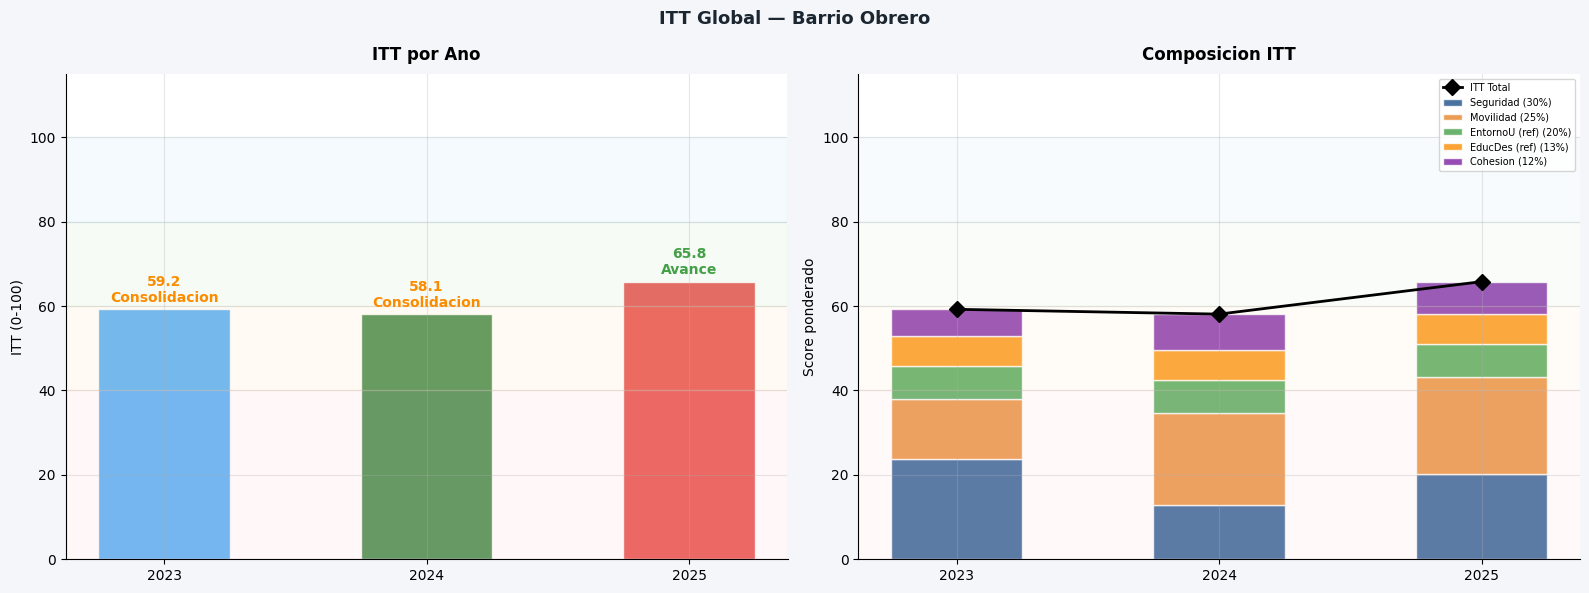

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('ITT Global — Barrio Obrero', fontsize=13, fontweight='bold', color='#1B2631')
COLORES_ITT = ['#42A5F5','#2E7D32','#E53935']
band_configs = [(0,40,'#FFCDD2','Emergencia'),(40,60,'#FFE0B2','Consolidacion'),
                (60,80,'#C8E6C9','Avance'),(80,100,'#BBDEFB','Transformacion')]

ax1 = axes[0]
bars = ax1.bar(ANIOS, base['ITT'], color=COLORES_ITT, alpha=0.85, edgecolor='white', width=0.5)
for bar, val, nivel in zip(bars, base['ITT'], base['nivel']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}\n{nivel}', ha='center', va='bottom',
        fontsize=10, fontweight='bold', color=NIVEL_COLORS.get(nivel,'#1B2631'))
for y0,y1,c,l in band_configs: ax1.axhspan(y0,y1, alpha=0.15, color=c)
ax1.set_title('ITT por Ano', fontweight='bold', pad=10)
ax1.set_ylim(0,115); ax1.set_ylabel('ITT (0-100)'); ax1.set_xticks(ANIOS)

ax2 = axes[1]
dims = ['score_seguridad','score_movilidad','score_entorno_u','score_educ_des','score_cohesion']
dim_lbl = ['Seguridad','Movilidad','EntornoU (ref)','EducDes (ref)','Cohesion']
dim_p = [PESOS['Seguridad'],PESOS['Movilidad'],PESOS['EntornoU'],PESOS['EducDes'],PESOS['Cohesion']]
dim_c = [C_SEG, C_MOV, '#43A047', '#FB8C00', C_COH]
bottom = np.zeros(len(ANIOS))
for dim, lbl, peso, col in zip(dims, dim_lbl, dim_p, dim_c):
    vals = base[dim].values * peso
    ax2.bar(ANIOS, vals, bottom=bottom, label=f'{lbl} ({peso:.0%})', color=col, alpha=0.8, edgecolor='white', width=0.5)
    bottom += vals
ax2.plot(ANIOS, base['ITT'], 'D-', color='black', linewidth=2, markersize=8, label='ITT Total', zorder=5)
for y0,y1,c,l in band_configs: ax2.axhspan(y0,y1, alpha=0.1, color=c)
ax2.set_title('Composicion ITT', fontweight='bold', pad=10)
ax2.set_ylim(0,115); ax2.set_ylabel('Score ponderado'); ax2.set_xticks(ANIOS)
ax2.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.savefig('itt_obrero_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 16 — Radar ITT: 5 dimensiones


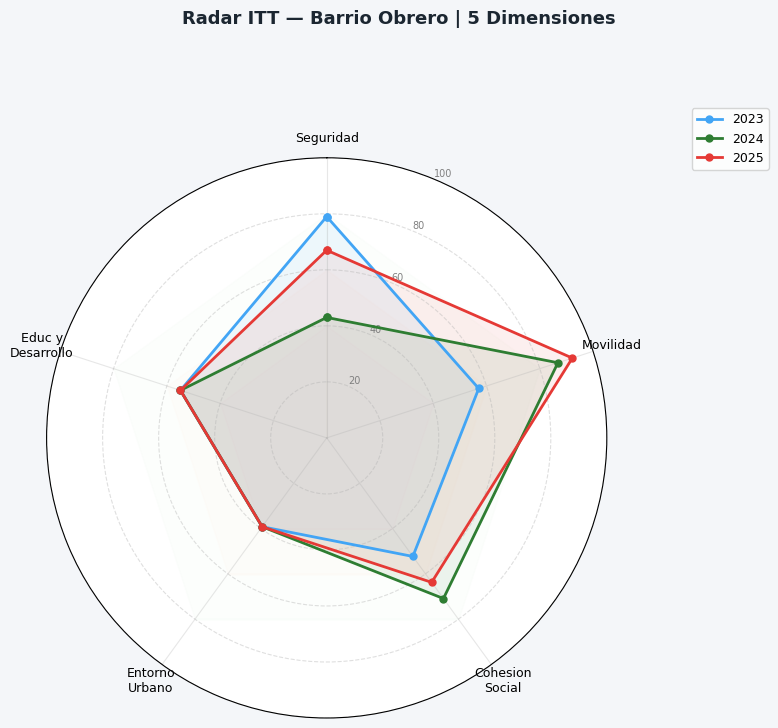

In [17]:
DIMS_LBL = ['Seguridad','Movilidad','Cohesion\nSocial','Entorno\nUrbano','Educ y\nDesarrollo']
N_DIMS = 5
angles = [i/N_DIMS*2*np.pi for i in range(N_DIMS)] + [0]
COLORES_R = ['#42A5F5','#2E7D32','#E53935']

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True), facecolor=BG)
fig.suptitle('Radar ITT — Barrio Obrero | 5 Dimensiones', fontsize=13, fontweight='bold', color='#1B2631')
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(DIMS_LBL, fontsize=9)
ax.set_ylim(0,100); ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=7, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
for y,c in [(40,'#FFCDD2'),(60,'#FFE0B2'),(80,'#C8E6C9')]: ax.fill_between(angles,0,y, alpha=0.04, color=c)

for idx, año in enumerate(ANIOS):
    row = base[base['año']==año].iloc[0]
    vals = [row['score_seguridad'],row['score_movilidad'],row['score_cohesion'],row['score_entorno_u'],row['score_educ_des']]
    vals_c = vals + [vals[0]]
    ax.plot(angles, vals_c, 'o-', color=COLORES_R[idx], linewidth=2, markersize=5, label=str(año))
    ax.fill(angles, vals_c, alpha=0.08, color=COLORES_R[idx])
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=9)
plt.tight_layout()
plt.savefig('itt_obrero_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 17 — Exportar a Excel


In [ ]:
EXPORT_PATH = 'ITT_Barrio_Obrero.xlsx'
with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    base.round(2).to_excel(writer, sheet_name='ITT_Anual', index=False)
    corr_trim.to_excel(writer, sheet_name='Series_Trimestrales', index=False)

    # Datos estaticos
    est = pd.DataFrame({'Elemento':['Arboles DAGMA','Sedes Educativas','CAI/MECAL'],
        'Cantidad':[len(raw_arb['features']),len(raw_sed['features']),len(raw_cai['features'])]})
    est.to_excel(writer, sheet_name='Datos_Estaticos', index=False)

    # Umbrales
    refs_df = pd.DataFrame([
        {'Indicador':ind,'ref_min':rmin,'ref_max':rmax,'Inverso':inv,'Descripcion':desc}
        for ind,(rmin,rmax,inv,desc) in REFS.items()
    ])
    refs_df.to_excel(writer, sheet_name='Umbrales_RefMinMax', index=False)

    # Metodologia
    met = pd.DataFrame({'Elemento':[
        'Indice','Zona','Periodo','Normalizacion',
        'Peso Seguridad','Peso Movilidad','Peso EntornoU','Peso EducDes','Peso Cohesion',
        'Entorno Urbano','Educ y Desarrollo','Vulnerabilidad ref',
        'ITT Global','Nivel 1','Nivel 2','Nivel 3','Nivel 4'],
    'Descripcion':[
        'Indice de Transformacion Territorial',
        'Barrio Obrero — Comuna 9, Cali',
        f'{ANIOS[0]}-{ANIOS[-1]}',
        'ref_min/ref_max fijos por indicador (juicio experto)',
        f'{PESOS["Seguridad"]:.0%}',f'{PESOS["Movilidad"]:.0%}',
        f'{PESOS["EntornoU"]:.0%} — ref={REF_ENTORNO_U}',
        f'{PESOS["EducDes"]:.0%} — ref={REF_EDUC_DES}',
        f'{PESOS["Cohesion"]:.0%}',
        f'{globals().get("FUENTE_ENTORNO_U", "Entorno Urbano")}: {REF_ENTORNO_U} | {globals().get("DETALLE_ENTORNO_U", "Sin detalle adicional")}',
        f'Score fijo={REF_EDUC_DES} (Pulmon de Oriente)',
        f'{REF_VULNERABILIDAD} (Sec. Bienestar Social)',
        'ITT = 0.30*Seg + 0.25*Mov + 0.20*EntU + 0.13*EyD + 0.12*Coh',
        '0-40 Emergencia','40-60 Consolidacion','60-80 Avance','80-100 Transformacion']
    })
    met.to_excel(writer, sheet_name='Metodologia', index=False)

print(f'Exportado: {EXPORT_PATH}')
print('Hojas: ITT_Anual | Series_Trimestrales | Datos_Estaticos | Umbrales_RefMinMax | Metodologia')
